<a href="https://colab.research.google.com/github/shrav-jally/DL_Lab_Sem6/blob/main/DLLabCIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#loading, preprocessing and extracting shape
import keras
from keras import layers, datasets
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset (Integrated in Keras)
(X_train_full, y_train_full), (X_test_full, y_test_full) = datasets.cifar10.load_data()

# 2. Extract and print Shapes/Sizes
print(f"Full Training set shape: {X_train_full.shape}") # (50000, 32, 32, 3)
print(f"Full Test set shape: {X_test_full.shape}")     # (10000, 32, 32, 3)
print(f"Image Resolution: {X_train_full.shape[1]}x{X_train_full.shape[2]}")
print(f"Channels: {X_train_full.shape[3]} (RGB)")

# 3. Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test_full = X_test_full.astype('float32') / 255.0

# 4. Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Full Training set shape: (50000, 32, 32, 3)
Full Test set shape: (10000, 32, 32, 3)
Image Resolution: 32x32
Channels: 3 (RGB)


In [ ]:
#inducing overfitting through split
from sklearn.model_selection import train_test_split

# We will only use 5% of the total data for training to force the model to overfit
# 5% of 50,000 = 2,500 images (still more than CMU, but small for CIFAR)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_full, y_train_full,
    test_size=0.95,
    stratify=y_train_full,
    random_state=42
)

# Use the rest for a large Validation and Test set to check generalization
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"Intentionally small Train set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")

Intentionally small Train set: 2500 images
Validation set: 23750 images


In [ ]:
#baseline cnn
from keras import models, layers

def build_baseline_model():
    model = models.Sequential([
        # Layer 1: Look for simple edges/colors
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Look for more complex patterns
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: Final refinement of features
        layers.Conv2D(64, (3, 3), activation='relu'),

        # Head: Flatten the 3D features into 1D for classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax') # 10 class output
    ])
    return model

# Create and compile
baseline_model = build_baseline_model()
baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Train for 30 epochs
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.1285 - loss: 2.2966 - val_accuracy: 0.2028 - val_loss: 2.1631
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.2514 - loss: 2.0525 - val_accuracy: 0.3067 - val_loss: 1.8552
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.3549 - loss: 1.7862 - val_accuracy: 0.3301 - val_loss: 1.8296
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.3952 - loss: 1.6828 - val_accuracy: 0.3754 - val_loss: 1.6888
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4364 - loss: 1.5441 - val_accuracy: 0.4065 - val_loss: 1.6206
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4813 - loss: 1.4266 - val_accuracy: 0.4375 - val_loss: 1.5455
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.4835 - loss: 1.3630 - val_accuracy: 0.4403 - val_loss: 1.5765
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.5538 - loss: 1.2956 - val_accuracy: 0.

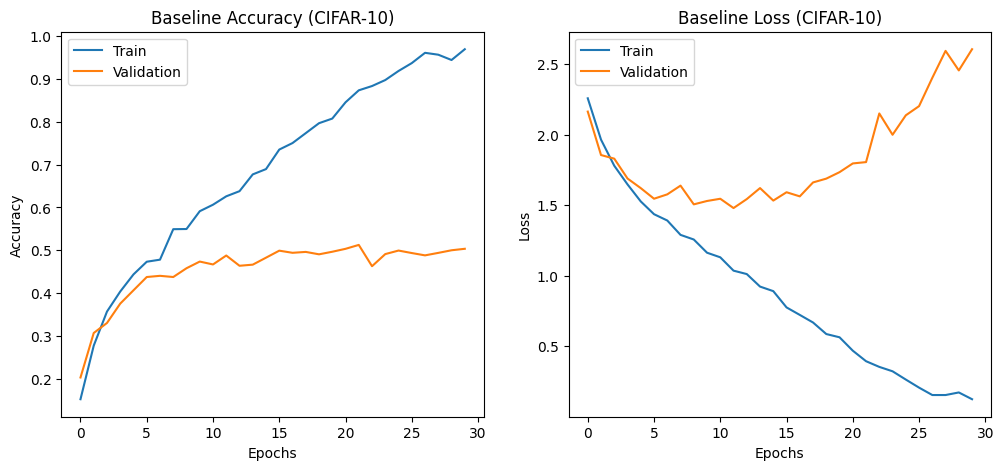

In [ ]:
#plotting learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.title("Baseline Accuracy (CIFAR-10)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.title("Baseline Loss (CIFAR-10)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


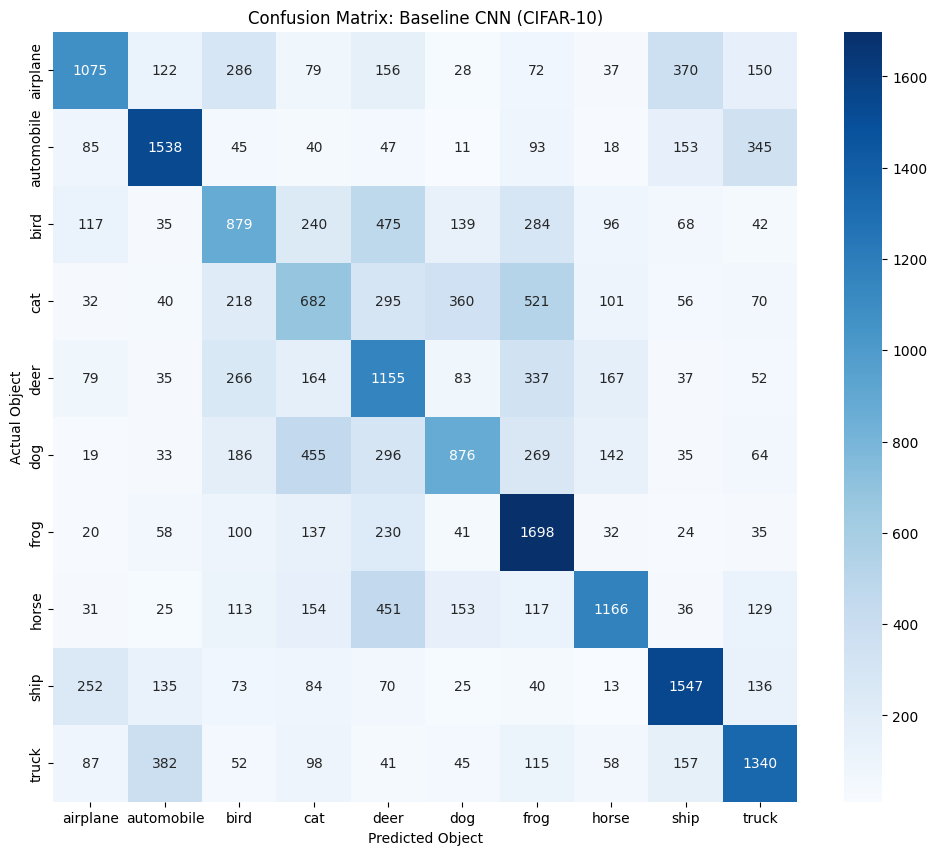

In [ ]:
#plotting confusion matrix
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get predictions (probabilities) for the validation set
y_pred_probs = baseline_model.predict(X_val)

# 2. Convert probabilities to class integers
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 3. Convert one-hot encoded validation labels back to integers
y_true_classes = np.argmax(y_val, axis=1)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 5. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix: Baseline CNN (CIFAR-10)")
plt.xlabel("Predicted Object")
plt.ylabel("Actual Object")
plt.show()


Training with Learning Rate: 0.01

Training with Learning Rate: 0.0001


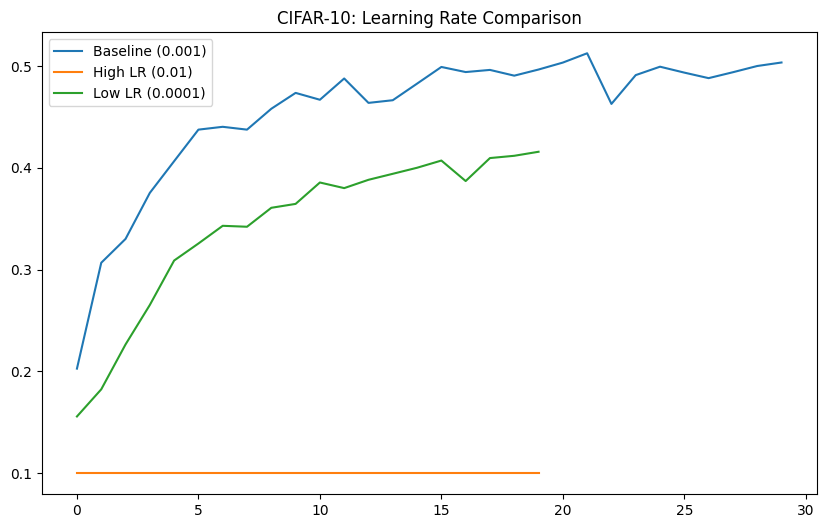

In [ ]:
#experimenting with learning rates
def train_lr_exp(lr_value, name):
    model = build_baseline_model() # Reset architecture
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_value),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"\nTraining with Learning Rate: {lr_value}")
    history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                        validation_data=(X_val, y_val), verbose=0)
    return history

# Run experiments
history_high_lr = train_lr_exp(0.01, "High")
history_low_lr = train_lr_exp(0.0001, "Low")

# Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (0.001)')
plt.plot(history_high_lr.history['val_accuracy'], label='High LR (0.01)')
plt.plot(history_low_lr.history['val_accuracy'], label='Low LR (0.0001)')
plt.title("CIFAR-10: Learning Rate Comparison")
plt.legend()
plt.show()


Training with Batch Size: 8

Training with Batch Size: 256


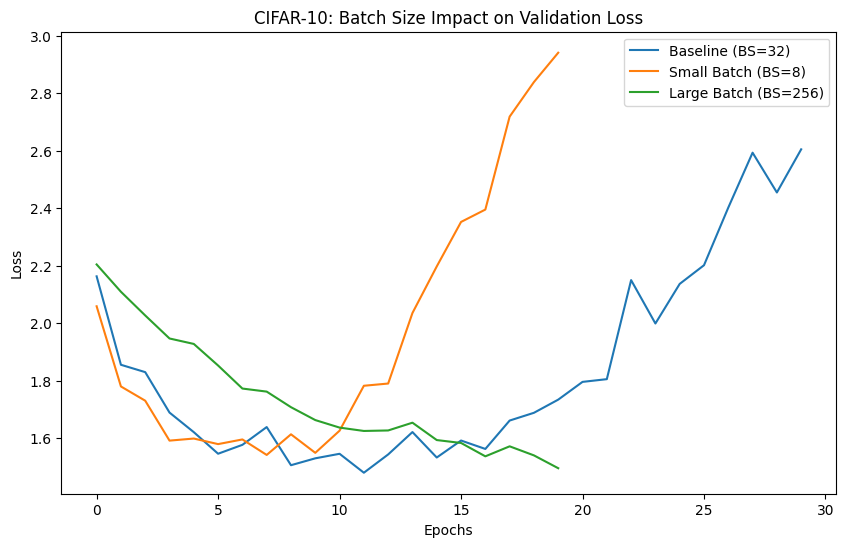

In [ ]:
#experimenting with batch sizes
def train_batch_exp(bs_value, name):
    model = build_baseline_model() # Reset architecture
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"\nTraining with Batch Size: {bs_value}")
    history = model.fit(X_train, y_train, epochs=20, batch_size=bs_value,
                        validation_data=(X_val, y_val), verbose=0)
    return history

# Run batch size experiments
history_small_bs = train_batch_exp(8, "Small")
history_large_bs = train_batch_exp(256, "Large")

# Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_loss'], label='Baseline (BS=32)')
plt.plot(history_small_bs.history['val_loss'], label='Small Batch (BS=8)')
plt.plot(history_large_bs.history['val_loss'], label='Large Batch (BS=256)')
plt.title("CIFAR-10: Batch Size Impact on Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

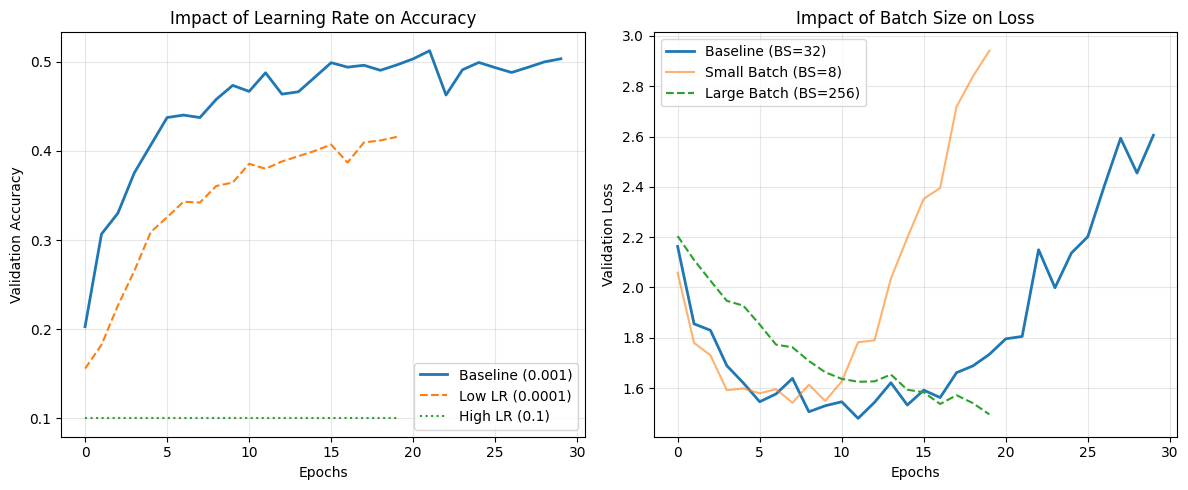

In [ ]:
#plotting learning rate and batch size variations
import matplotlib.pyplot as plt

# Set figure size for better readability
plt.rcParams['figure.figsize'] = [12, 5]

# --- Plot 1: Learning Rate Comparison ---
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (0.001)', linewidth=2)
plt.plot(history_low_lr.history['val_accuracy'], label='Low LR (0.0001)', linestyle='--')
plt.plot(history_high_lr.history['val_accuracy'], label='High LR (0.1)', linestyle=':')
plt.title("Impact of Learning Rate on Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Batch Size Comparison ---
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline (BS=32)', linewidth=2)
plt.plot(history_small_bs.history['val_loss'], label='Small Batch (BS=8)', alpha=0.6)
plt.plot(history_large_bs.history['val_loss'], label='Large Batch (BS=256)', linestyle='--')
plt.title("Impact of Batch Size on Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_bs_variation_comparison.png')

In [10]:
import matplotlib.pyplot as plt
from keras import models, layers, optimizers

def build_cifar_baseline():
    # Fresh model architecture for each experiment
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Define the 8 configurations
# We use the X_train defined in your earlier 5% split
cifar_experiments = [
    {"name": "1. Batch GD", "opt": optimizers.SGD(0.01), "bs": len(X_train)},
    {"name": "2. Stochastic GD", "opt": optimizers.SGD(0.01), "bs": 1},
    {"name": "3. Mini-batch GD", "opt": optimizers.SGD(0.01), "bs": 32},
    {"name": "4. SGD + Momentum", "opt": optimizers.SGD(0.01, momentum=0.9), "bs": 32},
    {"name": "5. Nesterov", "opt": optimizers.SGD(0.01, momentum=0.9, nesterov=True), "bs": 32},
    {"name": "6. AdaGrad", "opt": optimizers.Adagrad(0.01), "bs": 32},
    {"name": "7. RMSProp", "opt": optimizers.RMSprop(0.001), "bs": 32},
    {"name": "8. Adam", "opt": optimizers.Adam(0.001), "bs": 32},
]

all_histories = {}

# Run the tournament
for exp in cifar_experiments:
    print(f"Testing: {exp['name']}...")
    model = build_cifar_baseline()
    model.compile(optimizer=exp['opt'], loss='categorical_crossentropy', metrics=['accuracy'])

    # We train for 15 epochs to observe convergence speed
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=15,
                        batch_size=exp['bs'],
                        verbose=0)
    all_histories[exp['name']] = history

print("Tournament Complete!")

Testing: 1. Batch GD...
Testing: 2. Stochastic GD...
Testing: 3. Mini-batch GD...
Testing: 4. SGD + Momentum...
Testing: 5. Nesterov...
Testing: 6. AdaGrad...
Testing: 7. RMSProp...
Testing: 8. Adam...
Tournament Complete!


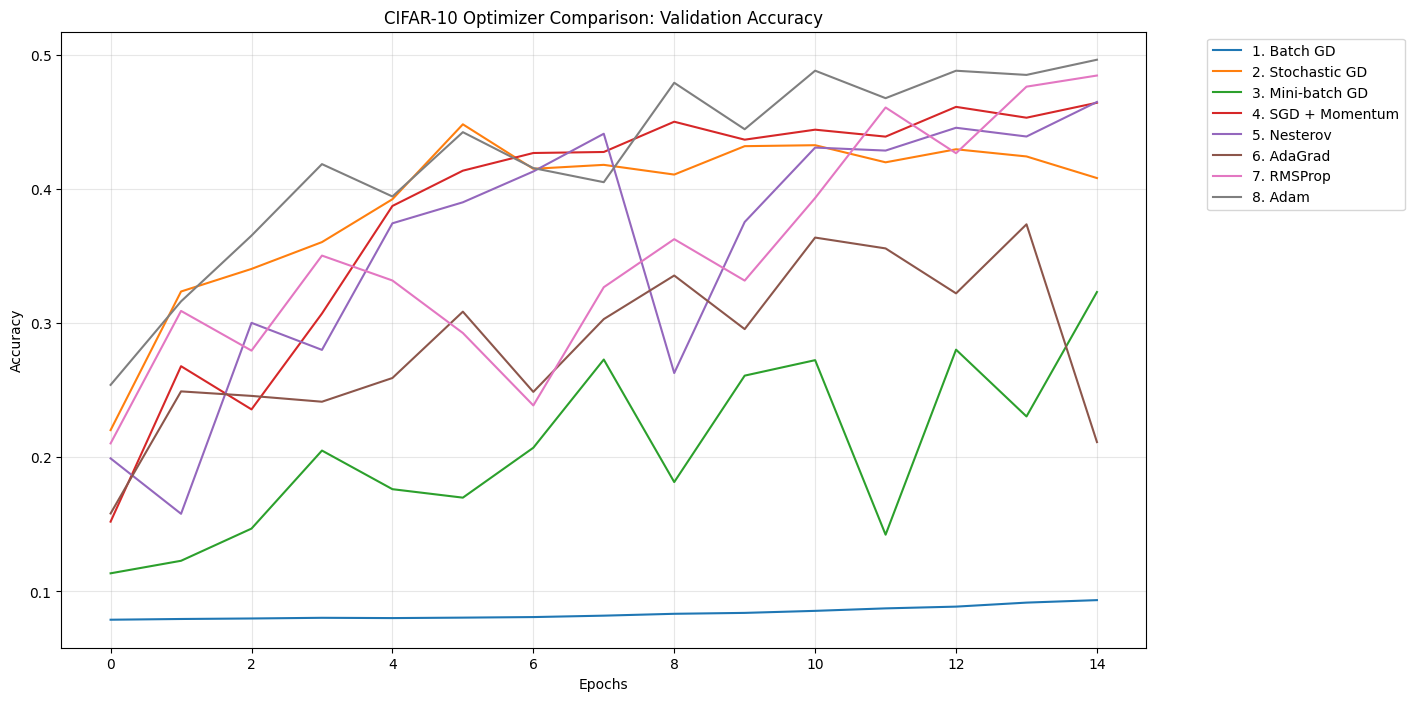

In [11]:
plt.figure(figsize=(14, 8))

for name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("CIFAR-10 Optimizer Comparison: Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
#implementing optimized model
from keras import regularizers

def build_optimized_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Conv Layer + L2 Regularization (Keeps weights small)
        layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Dropout: Randomly "turns off" 50% of neurons to force better learning
        layers.Dropout(0.5),

        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Final Optimized Run
optimized_model = build_optimized_cifar_model()
optimized_model.compile(
    optimizer=keras.optimizers.Adam(0.001), # Using the 'Adam' logic from your tournament
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_optimized = optimized_model.fit(
    X_train, y_train,
    epochs=50, # More epochs because Dropout makes learning slower but better
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.1424 - loss: 2.3176 - val_accuracy: 0.1848 - val_loss: 2.1695
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.2218 - loss: 2.1356 - val_accuracy: 0.2904 - val_loss: 1.9755
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.3195 - loss: 1.9062 - val_accuracy: 0.3159 - val_loss: 1.9558
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.3314 - loss: 1.8507 - val_accuracy: 0.3676 - val_loss: 1.7660
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.3792 - loss: 1.7334 - val_accuracy: 0.3933 - val_loss: 1.7022
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.4143 - loss: 1.6173 - val_accuracy: 0.3914 - val_loss: 1.6916
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.4219 - loss: 1.6141 - val_accuracy: 0.3982 - val_loss: 1.7120
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.4409 - loss: 1.5739 - val_accuracy: 

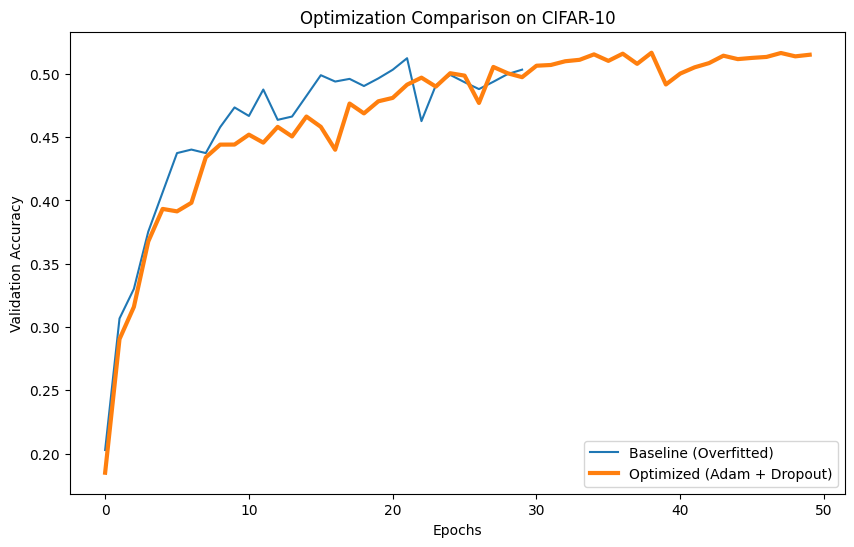

In [13]:
#visualizing improvement
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Overfitted)')
plt.plot(history_optimized.history['val_accuracy'], label='Optimized (Adam + Dropout)', linewidth=3)
plt.title("Optimization Comparison on CIFAR-10")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

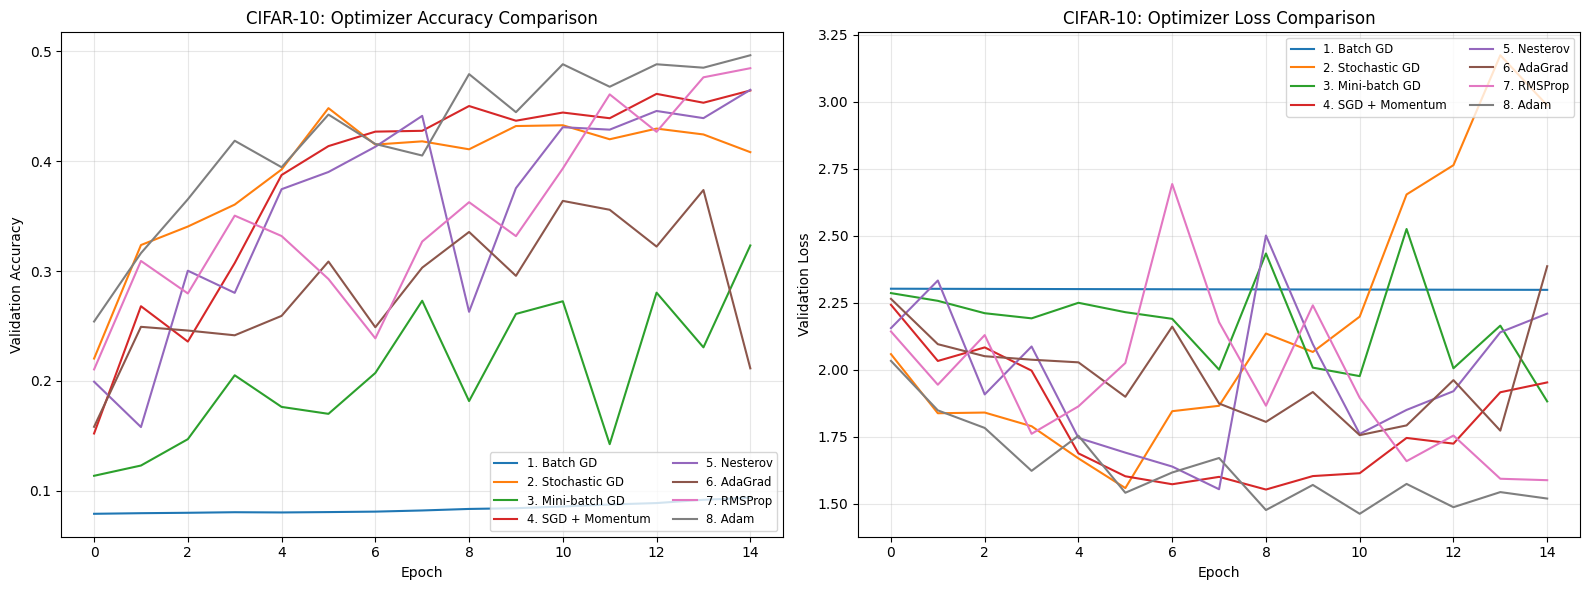

In [15]:
import matplotlib.pyplot as plt

# Set the figure size to be wide like your professor's example
plt.figure(figsize=(16, 6))

# --- Plot 1: Validation Accuracy Comparison ---
plt.subplot(1, 2, 1)
# Using 'all_histories' which contains your 8 optimizer results
for name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('CIFAR-10: Optimizer Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)

# --- Plot 2: Validation Loss Comparison ---
plt.subplot(1, 2, 2)
for name, history in all_histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title('CIFAR-10: Optimizer Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


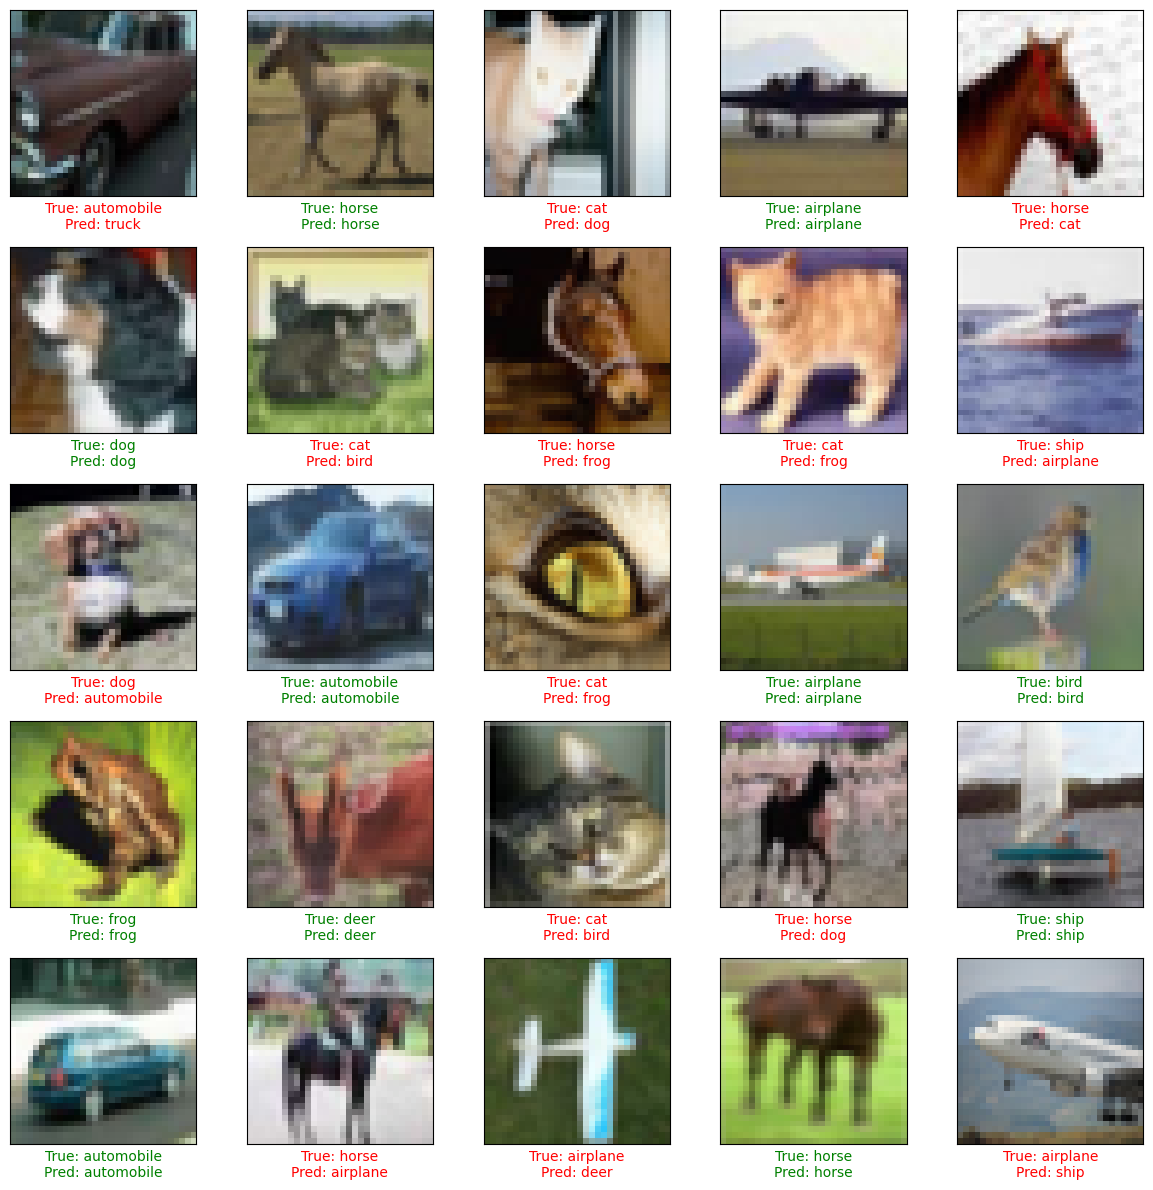

In [16]:
#visualizing predictions
# 1. Choose the 'Best' model from your tournament (likely Adam)
# Assuming 'model' is your best-performing version
predictions = model.predict(X_test)

# 2. Plot a 5x5 grid of images with True and Predicted labels
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Show the color image
    plt.imshow(X_test[i])

    true_label = class_names[np.argmax(y_test[i])]
    pred_label = class_names[np.argmax(predictions[i])]

    # Color coding: Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'

    plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()

In [17]:
#L2 regularization
from keras import regularizers, models, layers

def build_l2_cifar_model(l2_value=0.01):
    model = models.Sequential([
        # Layer 1: Conv + L2
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Conv + L2
        layers.Conv2D(64, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: Conv + L2
        layers.Conv2D(64, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),

        # Classifier Head + L2
        layers.Flatten(),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Initialize, Compile, and Train
model_l2 = build_l2_cifar_model(l2_value=0.01) # Using professor's 0.01 value

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CIFAR-10 with L2 Regularization...")
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Training CIFAR-10 with L2 Regularization...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.1014 - loss: 3.9968 - val_accuracy: 0.1466 - val_loss: 2.7116
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.1981 - loss: 2.5686 - val_accuracy: 0.1952 - val_loss: 2.3547
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.2332 - loss: 2.2796 - val_accuracy: 0.2049 - val_loss: 2.3783
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 318ms/step - accuracy: 0.2339 - loss: 2.2379 - val_accuracy: 0.2491 - val_loss: 2.1929
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.2730 - loss: 2.1296 - val_accuracy: 0.2703 - val_loss: 2.1304
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.2983 - loss: 2.1366 - val_accuracy: 0.3255 - val_loss: 2.0218
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.3703 - loss: 1.9600 - val_accuracy: 0.3158 - val_loss: 2.0121
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - ac

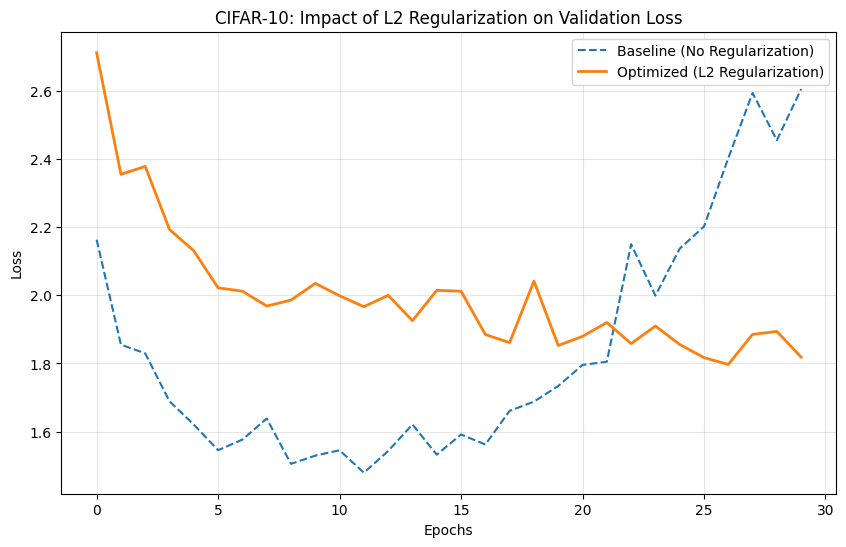

In [18]:
#visualizing the fix: baseline vs. L2
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_loss'], label='Baseline (No Regularization)', linestyle='--')
plt.plot(history_l2.history['val_loss'], label='Optimized (L2 Regularization)', linewidth=2)

plt.title("CIFAR-10: Impact of L2 Regularization on Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
#data augmentation
#setting up augmentation generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the augmentation strategy
datagen = ImageDataGenerator(
    rotation_range=15,      # Rotate images by up to 15 degrees
    width_shift_range=0.1,  # Shift horizontally by 10%
    height_shift_range=0.1, # Shift vertically by 10%
    horizontal_flip=True,   # Flip images horizontally
    zoom_range=0.1          # Randomly zoom in/out by 10%
)

# Compute internal data stats (necessary for some augmentations)
datagen.fit(X_train)

In [20]:
#train model with augmented data
# Re-build your best model architecture
final_model = build_l2_cifar_model(l2_value=0.001)

final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train using the 'flow' method to generate images on the fly
history_augmented = final_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50, # Augmentation usually requires more epochs to converge
    validation_data=(X_val, y_val),
    steps_per_epoch=len(X_train) // 64
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 313ms/step - accuracy: 0.1321 - loss: 2.4743 - val_accuracy: 0.2120 - val_loss: 2.2365
Epoch 2/50
 1/39 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.2031 - loss: 2.2212

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 0.2031 - loss: 2.2212 - val_accuracy: 0.2339 - val_loss: 2.1914
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - accuracy: 0.1916 - loss: 2.2038 - val_accuracy: 0.2680 - val_loss: 2.0716
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.2656 - loss: 2.0093 - val_accuracy: 0.2829 - val_loss: 2.0381
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.2717 - loss: 2.0474 - val_accuracy: 0.3109 - val_loss: 1.9439
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.2500 - loss: 2.2032 - val_accuracy: 0.2848 - val_loss: 1.9911
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.2740 - loss: 1.9856 - val_accuracy: 0.3338 - val_loss: 1.8934
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.2969 - loss: 2.0153 - val_accuracy: 0.3346 - val_loss: 1.8881
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.3393 - loss: 1.9172 - val_accuracy: 0.2949 - va

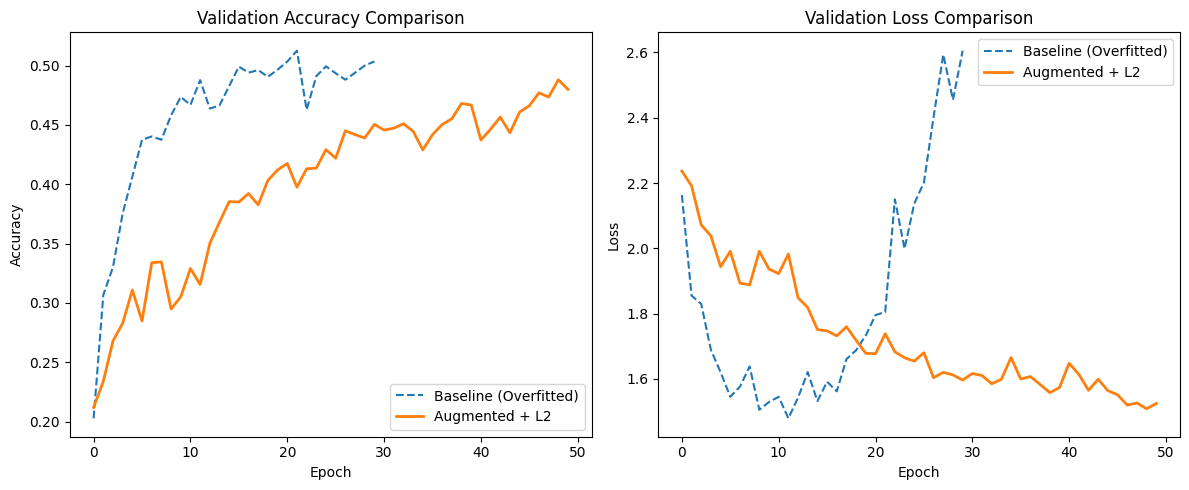

In [21]:
#visualizing the fix: baseline vs. augmentation
plt.figure(figsize=(12, 5))

# Plot Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Overfitted)', linestyle='--')
plt.plot(history_augmented.history['val_accuracy'], label='Augmented + L2', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline (Overfitted)', linestyle='--')
plt.plot(history_augmented.history['val_loss'], label='Augmented + L2', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',   # Watch the validation accuracy
    patience=5,               # Give it 5 epochs to improve before quitting
    restore_best_weights=True # Make sure we keep the best version of the model
)

# 2. Build and Compile
model_es = build_l2_cifar_model(l2_value=0.001)
model_es.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train (We can set epochs high, like 100, because Early Stopping will handle it)
print("Training with Early Stopping...")
history_es = model_es.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Training with Early Stopping...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 343ms/step - accuracy: 0.1155 - loss: 2.4769 - val_accuracy: 0.1923 - val_loss: 2.2483
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.2370 - loss: 2.1955 - val_accuracy: 0.2653 - val_loss: 2.0679
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.3006 - loss: 2.0234 - val_accuracy: 0.3171 - val_loss: 1.9157
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.3358 - loss: 1.8792 - val_accuracy: 0.3457 - val_loss: 1.8471
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.3608 - loss: 1.7872 - val_accuracy: 0.3671 - val_loss: 1.8076
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.3881 - loss: 1.7327 - val_accuracy: 0.3877 - val_loss: 1.7480
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.4252 - loss: 1.6773 - val_accuracy: 0.3425 - val_loss: 1.8388
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accur

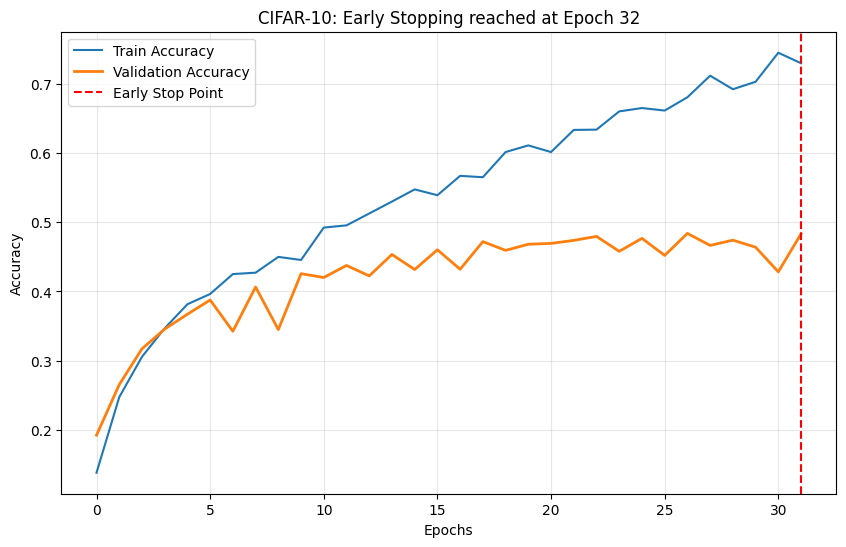

In [23]:
#visualizing stop point
plt.figure(figsize=(10, 6))
plt.plot(history_es.history['accuracy'], label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

# Find the epoch where it stopped
stopped_epoch = len(history_es.history['accuracy'])
plt.axvline(x=stopped_epoch-1, color='r', linestyle='--', label='Early Stop Point')

plt.title(f"CIFAR-10: Early Stopping reached at Epoch {stopped_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
#cifar-10 with dropout layers
#build, train dropout modelfrom keras import models, layers

def build_dropout_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Conv Blocks
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Classifier Head with Dropout
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),  # 🔹 Dropout added (30%)

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),  # 🔹 Dropout added (30%)

        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and Train
model_dropout = build_dropout_cifar_model()
model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CIFAR-10 with Dropout...")
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Training CIFAR-10 with Dropout...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - accuracy: 0.1323 - loss: 2.2839 - val_accuracy: 0.2351 - val_loss: 2.0843
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.2118 - loss: 2.1062 - val_accuracy: 0.2618 - val_loss: 1.9919
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.2630 - loss: 1.9893 - val_accuracy: 0.2888 - val_loss: 1.9416
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.3145 - loss: 1.8991 - val_accuracy: 0.3608 - val_loss: 1.7356
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.3491 - loss: 1.7722 - val_accuracy: 0.3814 - val_loss: 1.6804
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - accuracy: 0.3638 - loss: 1.6954 - val_accuracy: 0.3568 - val_loss: 1.7856
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.4057 - loss: 1.6404 - val_accuracy: 0.4194 - val_loss: 1.5929
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.43

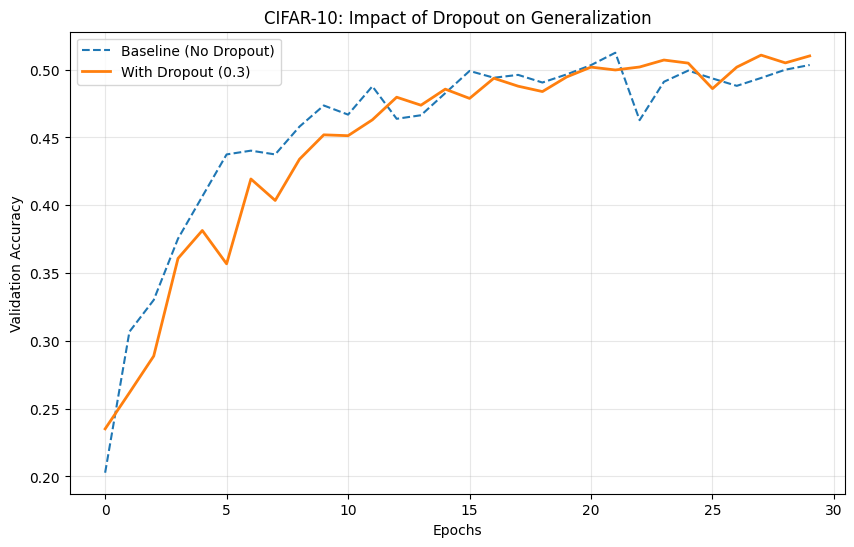

In [26]:
#visualizing smoothing effect
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (No Dropout)', linestyle='--')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout (0.3)', linewidth=2)

plt.title("CIFAR-10: Impact of Dropout on Generalization")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
#adding noise
import numpy as np

# --- 1. Add Input Noise (Gaussian Noise) ---
noise_factor = 0.1
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.) # Keep pixels in [0, 1] range

# --- 2. Add Output Noise (Label Flipping) ---
# Randomly flip 10% of the training labels
y_train_noisy = y_train.copy()
noise_ratio = 0.1
num_samples = int(noise_ratio * y_train_noisy.shape[0])
random_indices = np.random.choice(y_train_noisy.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 10)
    # Convert back to one-hot for consistency
    y_train_noisy[idx] = keras.utils.to_categorical(random_label, 10)

print(f"Applied Gaussian noise and flipped {num_samples} labels.")

Applied Gaussian noise and flipped 250 labels.


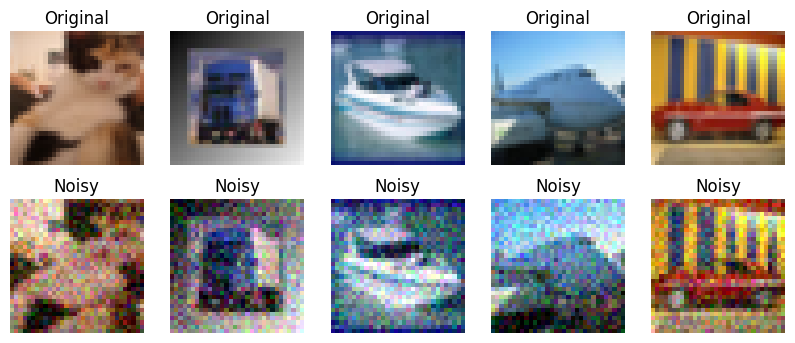

In [28]:
#visualize
plt.figure(figsize=(10, 4))
for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_train_noisy[i])
    plt.title("Noisy")
    plt.axis('off')
plt.show()

In [29]:
#training and analyzing noise robustness
# Build the model (using your best architecture)
model_noisy = build_l2_cifar_model(l2_value=0.001)

model_noisy.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train on Noisy Input and Noisy Labels
history_noisy = model_noisy.fit(
    X_train_noisy, y_train_noisy,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val) # Validate on CLEAN data to see true performance
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.1286 - loss: 2.4755 - val_accuracy: 0.1786 - val_loss: 2.2710
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.1703 - loss: 2.2819 - val_accuracy: 0.2369 - val_loss: 2.1605
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.2248 - loss: 2.1649 - val_accuracy: 0.2495 - val_loss: 2.1188
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.2455 - loss: 2.1402 - val_accuracy: 0.2779 - val_loss: 2.0619
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.2600 - loss: 2.0953 - val_accuracy: 0.3147 - val_loss: 1.9396
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.3277 - loss: 1.9631 - val_accuracy: 0.3558 - val_loss: 1.8575
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.3447 - loss: 1.9175 - val_accuracy: 0.3737 - val_loss: 1.8157
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.3756 - loss: 1.8513 - val_accuracy: